In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
df = pd.read_csv("../excel/IT_Service_Desk_SLA_Cleaned_No_Missing_12000.csv")

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully
Rows: 12000
Columns: 25


In [6]:
df.head()

,Ticket_ID,Created_Date,First_Response_Date,Resolved_Date,Priority,Category,Sub_Category,Department,Assigned_Team,Assigned_Agent,Channel,Status,SLA_Target_Hours,Response_Time_Hours,Resolution_Time_Hours,Response_SLA_Breached,Resolution_SLA_Breached,Escalated,Reopened,CSAT_Score,Created_Year,Created_Month,Created_Day,Created_Hour,SLA_Status
0,INC100000,2025-01-01 08:18:00,2025-01-01 08:59:30,2025-01-01 16:04:29,P2 - High,Email & Collaboration,Teams/Chat Issue,Customer Support,Network Team,Agent 17,Chat,Resolved,8,0.69,7.77,No,No,No,No,4,2025,2025-01,Wednesday,8,Met
1,INC100001,2025-01-01 08:31:00,2025-01-01 10:13:34,2025-01-01 22:26:29,P4 - Low,Database,Database Access,Customer Support,Infrastructure Team,Agent 03,Email,Resolved,48,1.71,13.92,No,No,No,No,5,2025,2025-01,Wednesday,8,Met
2,INC100002,2025-01-01 10:26:00,2025-01-01 12:15:23,2025-01-02 01:33:04,P3 - Medium,Network,VPN Issue,IT,Network Team,Agent 12,Chat,Resolved,24,1.82,15.12,No,No,No,No,4,2025,2025-01,Wednesday,10,Met
3,INC100003,2025-01-01 10:38:00,2025-01-01 15:10:54,2025-01-02 09:00:21,P3 - Medium,Cloud & Infrastructure,Server Issue,Sales,Application Support,Agent 01,Portal,Resolved,24,4.55,22.37,No,No,No,No,3,2025,2025-01,Wednesday,10,Met
4,INC100004,2025-01-01 10:46:00,2025-01-01 14:25:23,2025-01-02 10:36:51,P3 - Medium,Access Management,Permission Request,IT,Service Desk L2,Agent 06,Portal,Resolved,24,3.66,23.85,No,No,No,No,4,2025,2025-01,Wednesday,10,Met


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Ticket_ID                12000 non-null  str    
 1   Created_Date             12000 non-null  str    
 2   First_Response_Date      12000 non-null  str    
 3   Resolved_Date            12000 non-null  str    
 4   Priority                 12000 non-null  str    
 5   Category                 12000 non-null  str    
 6   Sub_Category             12000 non-null  str    
 7   Department               12000 non-null  str    
 8   Assigned_Team            12000 non-null  str    
 9   Assigned_Agent           12000 non-null  str    
 10  Channel                  12000 non-null  str    
 11  Status                   12000 non-null  str    
 12  SLA_Target_Hours         12000 non-null  int64  
 13  Response_Time_Hours      12000 non-null  float64
 14  Resolution_Time_Hours    12000 no

In [9]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate Ticket IDs:", df["Ticket_ID"].duplicated().sum())

Missing values:
Ticket_ID                  0
Created_Date               0
First_Response_Date        0
Resolved_Date              0
Priority                   0
Category                   0
Sub_Category               0
Department                 0
Assigned_Team              0
Assigned_Agent             0
Channel                    0
Status                     0
SLA_Target_Hours           0
Response_Time_Hours        0
Resolution_Time_Hours      0
Response_SLA_Breached      0
Resolution_SLA_Breached    0
Escalated                  0
Reopened                   0
CSAT_Score                 0
Created_Year               0
Created_Month              0
Created_Day                0
Created_Hour               0
SLA_Status                 0
dtype: int64

Duplicate rows: 0
Duplicate Ticket IDs: 0


In [10]:
df.describe()

,SLA_Target_Hours,Response_Time_Hours,Resolution_Time_Hours,CSAT_Score,Created_Year,Created_Hour
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,25.397667,2.451983,21.731763,3.770250,2025.322667,11.518917
std,14.890344,1.573462,18.510863,0.657141,0.467516,6.925543
min,4.000000,0.200000,1.310000,1.000000,2025.000000,0.000000
25%,8.000000,1.370000,10.090000,3.000000,2025.000000,5.750000
50%,24.000000,2.070000,16.610000,4.000000,2025.000000,11.000000
75%,48.000000,3.090000,27.090000,4.000000,2026.000000,18.000000
max,48.000000,18.020000,278.010000,5.000000,2026.000000,23.000000


In [11]:
sla_analysis = df["SLA_Status"].value_counts()

print(sla_analysis)

print("\nSLA Compliance Rate:",
      round((df["SLA_Status"] == "Met").mean() * 100, 2), "%")

SLA_Status
Met         7200
Breached    4800
Name: count, dtype: int64

SLA Compliance Rate: 60.0 %


In [12]:
priority_analysis = df.groupby("Priority").agg(
    Total_Tickets=("Ticket_ID", "count"),
    Avg_Response_Hours=("Response_Time_Hours", "mean"),
    Avg_Resolution_Hours=("Resolution_Time_Hours", "mean"),
    Avg_CSAT=("CSAT_Score", "mean")
).round(2)

priority_analysis

,Total_Tickets,Avg_Response_Hours,Avg_Resolution_Hours,Avg_CSAT
Priority,,,,
P1 - Critical,831,1.16,10.12,3.65
P2 - High,2422,1.89,16.73,3.61
P3 - Medium,5741,2.54,22.65,3.79
P4 - Low,3006,3.11,27.23,3.89


In [13]:
category_analysis = df.groupby("Category").agg(
    Total_Tickets=("Ticket_ID", "count"),
    Avg_Response_Hours=("Response_Time_Hours", "mean"),
    Avg_Resolution_Hours=("Resolution_Time_Hours", "mean"),
    Avg_CSAT=("CSAT_Score", "mean")
).round(2)

category_analysis

,Total_Tickets,Avg_Response_Hours,Avg_Resolution_Hours,Avg_CSAT
Category,,,,
Access Management,2155,2.48,20.44,3.79
Cloud & Infrastructure,1091,2.50,26.40,3.64
Database,699,2.43,25.31,3.68
Email & Collaboration,1377,2.43,20.61,3.80
Hardware,1687,2.42,19.79,3.82
Network,2048,2.42,20.74,3.81
Security,970,2.53,25.82,3.66
Software,1973,2.44,20.76,3.80


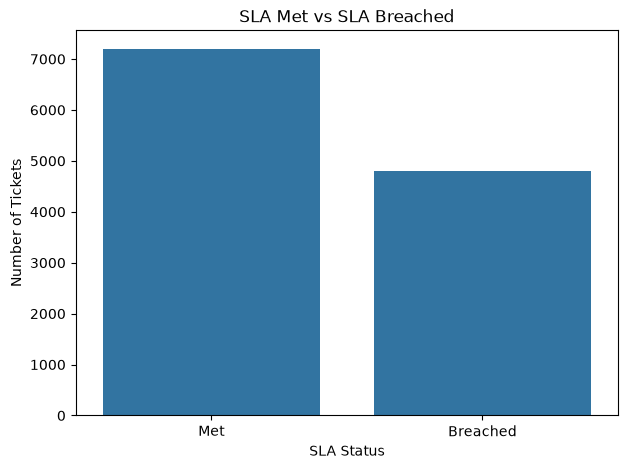

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="SLA_Status")

plt.title("SLA Met vs SLA Breached")
plt.xlabel("SLA Status")
plt.ylabel("Number of Tickets")

plt.show()

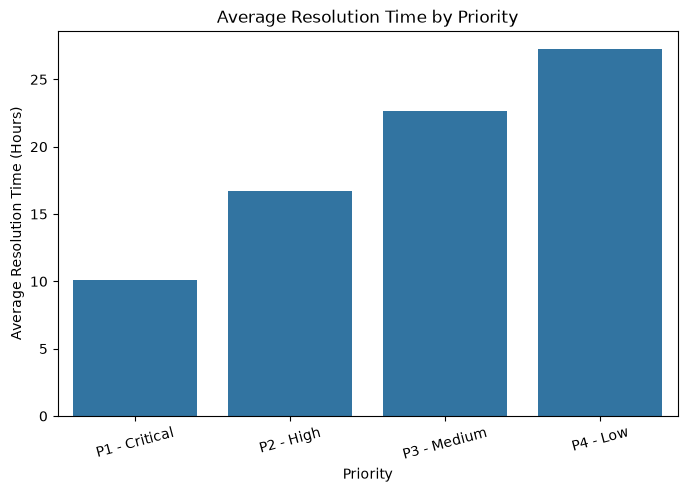

In [15]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=priority_analysis.reset_index(),
    x="Priority",
    y="Avg_Resolution_Hours"
)

plt.title("Average Resolution Time by Priority")
plt.xlabel("Priority")
plt.ylabel("Average Resolution Time (Hours)")

plt.xticks(rotation=15)
plt.show()

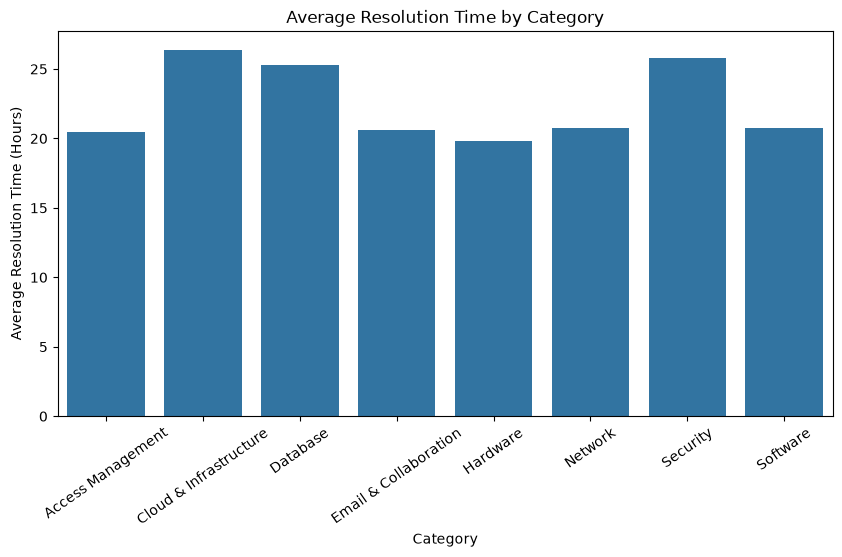

In [16]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=category_analysis.reset_index(),
    x="Category",
    y="Avg_Resolution_Hours"
)

plt.title("Average Resolution Time by Category")
plt.xlabel("Category")
plt.ylabel("Average Resolution Time (Hours)")

plt.xticks(rotation=35)
plt.show()